# Group Model Comparison

## 1. Individual Model Summary

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ---- Single source of truth: edit numbers HERE only ----
# accuracy / f1 are on the 1,066-review TEST set; gap = train accuracy - test accuracy (in percentage points)
results = [
    # IT number,   model,                       category,                    accuracy, weighted F1, gap (pp)
    ("IT25101779", "Logistic Regression",       "Linear classifier",          0.7552,   0.76,        4.6),
    ("IT25101746", "Linear SVM",                "Linear classifier",          0.7242,   0.72,        1.8),
    ("IT25101789", "Random Forest",             "Tree ensemble",              0.6595,   0.66,        3.7),
    ("IT25101763", "Multinomial Naive Bayes",   "Probabilistic classifier",   0.7477,   0.7471,      3.1),
    ("IT25101786", "LDA",                       "Dimensionality reduction",   0.7214,   0.7213,      3.9),
    ("IT25101771", "DistilBERT (1 epoch)",      "Deep learning (transformer)",0.8377,   0.84,        4.8),
]
comparison = pd.DataFrame(results, columns=["IT Number", "Model", "Category", "Test Accuracy", "Weighted F1", "Train-Test Gap (pp)"])
comparison.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

,IT Number,Model,Category,Test Accuracy,Weighted F1,Train-Test Gap (pp)
0,IT25101771,DistilBERT (1 epoch),Deep learning (transformer),0.8377,0.8400,4.8
1,IT25101779,Logistic Regression,Linear classifier,0.7552,0.7600,4.6
2,IT25101763,Multinomial Naive Bayes,Probabilistic classifier,0.7477,0.7471,3.1
3,IT25101746,Linear SVM,Linear classifier,0.7242,0.7200,1.8
4,IT25101786,LDA,Dimensionality reduction,0.7214,0.7213,3.9
5,IT25101789,Random Forest,Tree ensemble,0.6595,0.6600,3.7


## 2. Comparison Chart



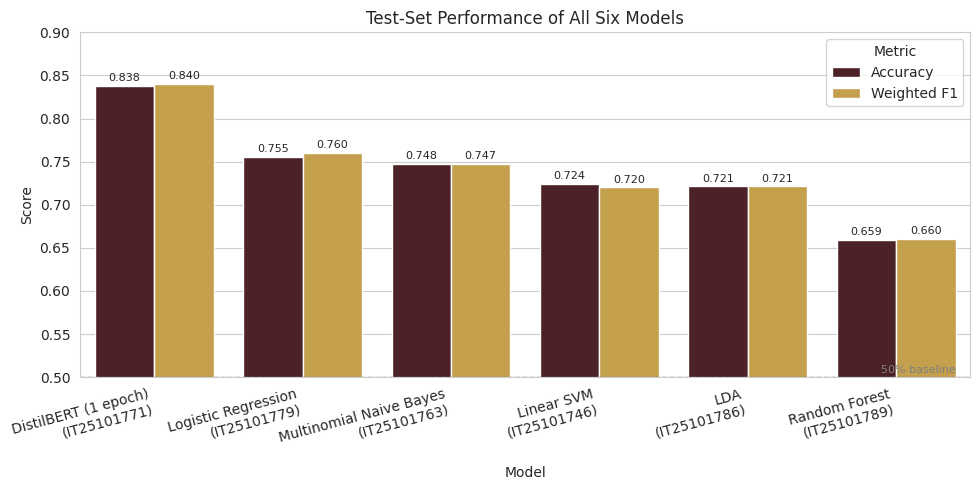

In [ ]:
order = comparison.sort_values("Test Accuracy", ascending=False)
labels = order["Model"] + "\n(" + order["IT Number"] + ")"

# --- Chart 1: accuracy and F1 ---
plot_df = pd.DataFrame({"Model": labels, "Accuracy": order["Test Accuracy"], "Weighted F1": order["Weighted F1"]})
melted = plot_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=melted, x="Model", y="Score", hue="Metric", palette=["#531A22", "#D8A838"])
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=8, padding=2)
plt.ylim(0.5, 0.9)
plt.axhline(0.5, color="grey", ls="--", lw=1)
plt.text(5.4, 0.505, "50% baseline", ha="right", fontsize=8, color="grey")
plt.title("Test-Set Performance of All Six Models")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

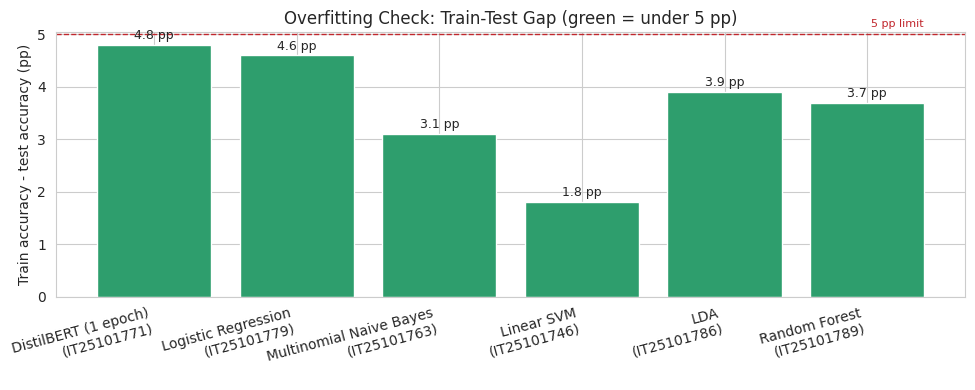

In [ ]:
# --- Chart 2: overfitting check (train-test gap) ---
plt.figure(figsize=(10, 4))
colors = ["#2E9E6D" if x < 5 else "#C1272D" for x in order["Train-Test Gap (pp)"]]
ax = plt.bar(labels, order["Train-Test Gap (pp)"], color=colors)
plt.bar_label(ax, fmt="%.1f pp", fontsize=9, padding=2)
plt.axhline(5, color="#C1272D", ls="--", lw=1)
plt.text(5.4, 5.15, "5 pp limit", ha="right", fontsize=8, color="#C1272D")
plt.ylabel("Train accuracy - test accuracy (pp)")
plt.title("Overfitting Check: Train-Test Gap (green = under 5 pp)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 4. Choosing the Final Model

In [ ]:
LIMIT = 5.0
eligible = comparison[comparison["Train-Test Gap (pp)"] < LIMIT].sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
winner, runner_up = eligible.iloc[0], eligible.iloc[1]

print(f"Models passing the {LIMIT:.0f} pp overfitting check: {len(eligible)} of {len(comparison)}")
print(f"\nFINAL MODEL: {winner['Model']} ({winner['IT Number']})")
print(f"  Test accuracy : {winner['Test Accuracy']:.1%}   (next best: {runner_up['Model']} at {runner_up['Test Accuracy']:.1%})")
print(f"  Margin        : {(winner['Test Accuracy'] - runner_up['Test Accuracy'])*100:.1f} percentage points")
print(f"  Train-test gap: {winner['Train-Test Gap (pp)']:.1f} pp -> healthy generalisation")

Models passing the 5 pp overfitting check: 6 of 6

FINAL MODEL: DistilBERT (1 epoch) (IT25101771)
  Test accuracy : 83.8%   (next best: Logistic Regression at 75.5%)
  Margin        : 8.3 percentage points
  Train-test gap: 4.8 pp -> healthy generalisation
